In [1]:
%load_ext autoreload
%autoreload 2

!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [2]:
import torch
torch.cuda.empty_cache()

In [3]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [4]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')
dl = dm.train_dataloader()

INFO     | _get_names | Processing train
INFO     | _get_names | Processing all_missing
INFO     | _get_names | Track & Cam : MOO07_mapping_easy cam0
INFO     | setup | Train Dataset       : 586 samples
INFO     | _get_names | Processing val
INFO     | _get_names | Processing all_missing
INFO     | _get_names | Track & Cam : MOO07_mapping_easy cam0
INFO     | setup | Validation Dataset  : 586 samples


In [5]:
batch = next(iter(dl))
ref_patches, ref_keypoints, tar_patches, tar_keypoints, confidences = batch

ref_patches = ref_patches.unsqueeze(1)
tar_patches = tar_patches.unsqueeze(1)

print(f'{ref_patches.shape}')
print(f'{ref_keypoints.shape}')
print(f'{tar_patches.shape}')
print(f'{tar_keypoints.shape}')
print(f'{confidences.shape}')

torch.Size([100, 1, 82, 82])
torch.Size([100, 2])
torch.Size([100, 1, 82, 82])
torch.Size([100, 2])
torch.Size([100])


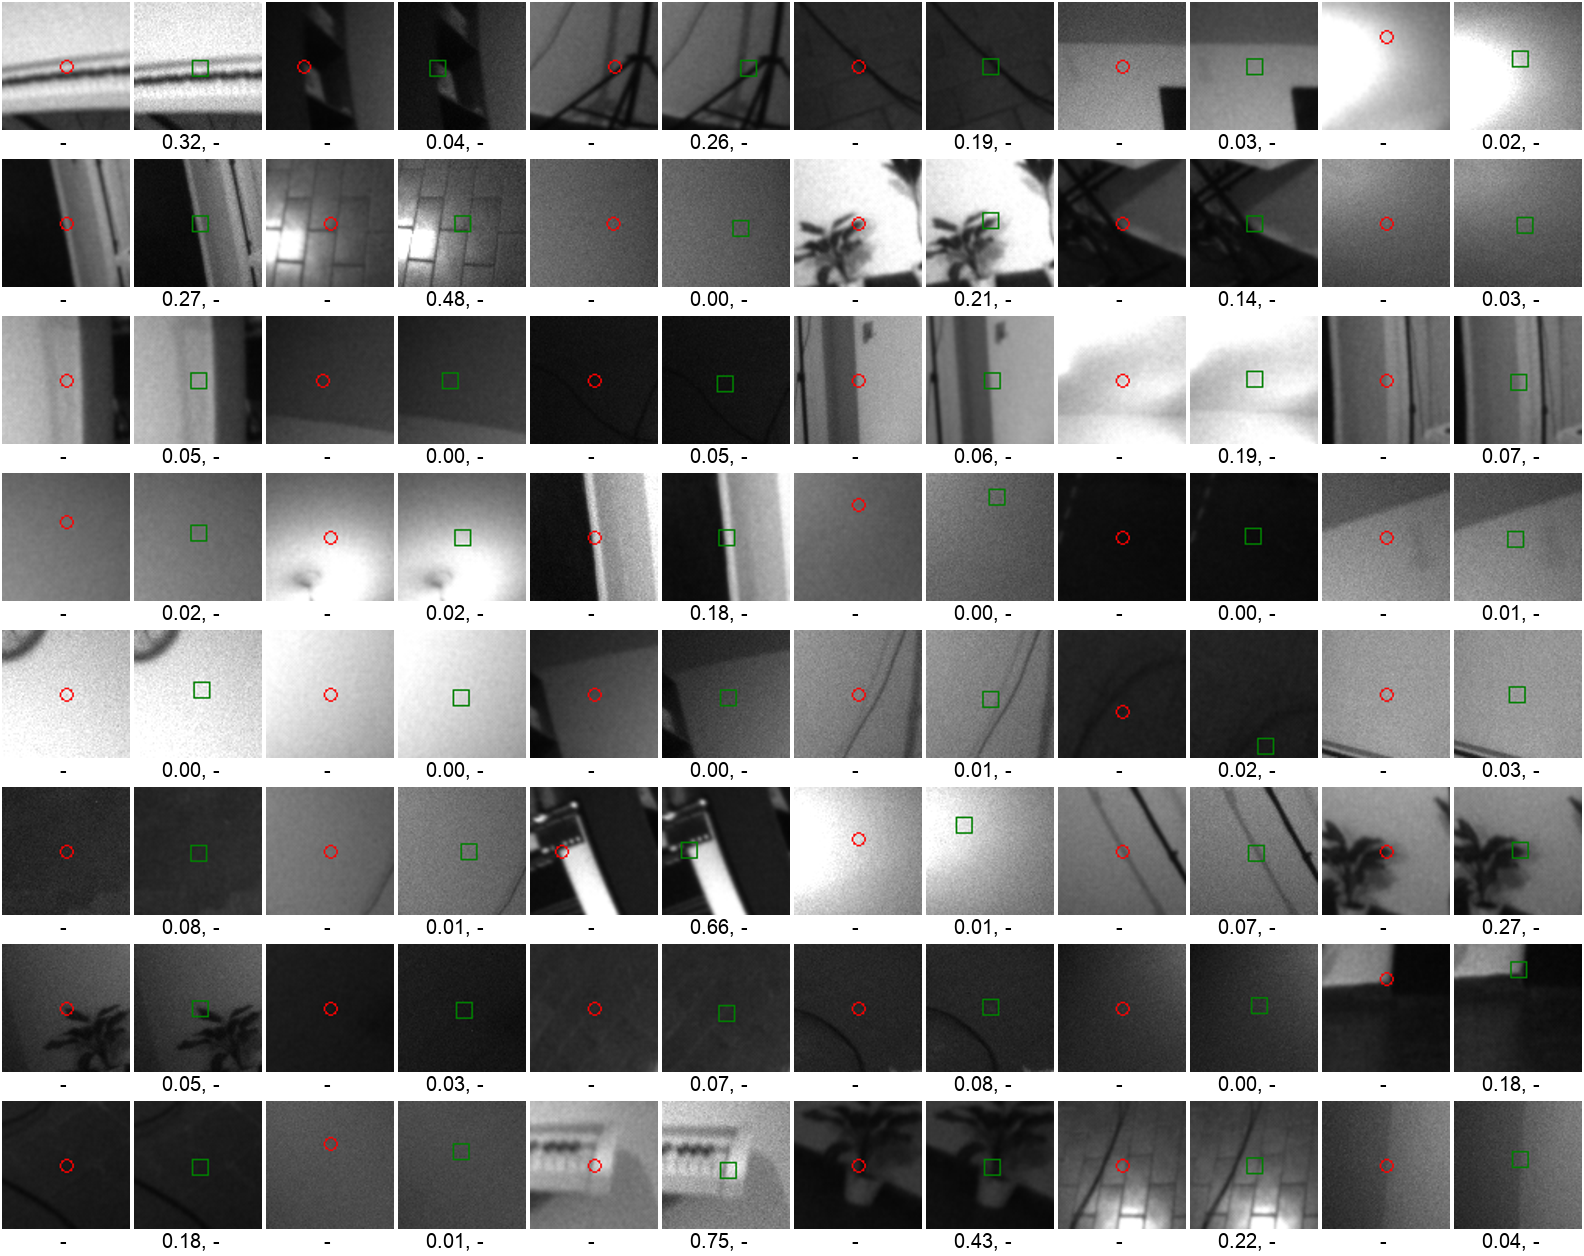

In [6]:
# batch = next(iter(dl))
# ref_patches, ref_keypoints, tar_patches, tar_keypoints, confidences = batch

# ref_patches = ref_patches.unsqueeze(1)
# tar_patches = tar_patches.unsqueeze(1)

count = 24 * 2

show_batch(
    ref_patches, tar_patches,
    ref_keypoints, tar_keypoints,
    tar_keypoints,

    confidence_pred=confidences,
    
    limit_count=count, 
    n_columns=6,
    just_gt=True,
)

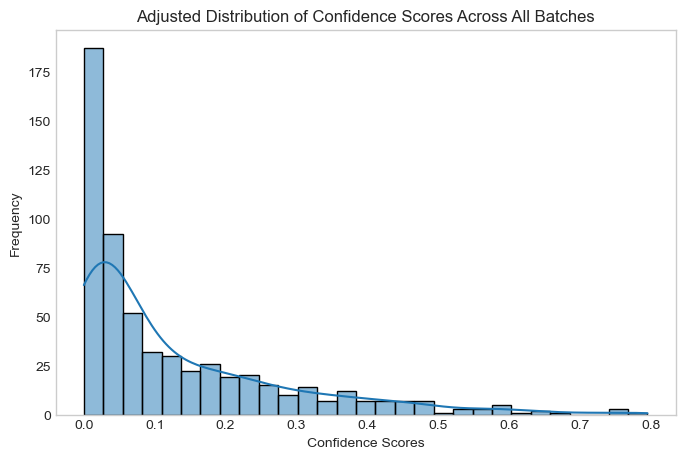

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confidence_distribution(dataloader, N=None):
    all_confidences = []
    
    for i, batch in enumerate(dataloader):
        if N is not None and i >= N:
            break
        _, _, _, _, confidences = batch
        all_confidences.extend(confidences.cpu().numpy())
    
    all_confidences = np.array(all_confidences)
    
    # Adjust for skewed distribution by equalizing bins
    min_conf, max_conf = all_confidences.min(), all_confidences.max()
    bins = np.linspace(min_conf, max_conf, 30)
    
    plt.figure(figsize=(8, 5))
    sns.histplot(all_confidences, bins=bins, kde=True)
    plt.xlabel("Confidence Scores")
    plt.ylabel("Frequency")
    plt.title("Adjusted Distribution of Confidence Scores Across All Batches")
    plt.grid()
    plt.show()


dl = dm.train_dataloader()
plot_confidence_distribution(dl)

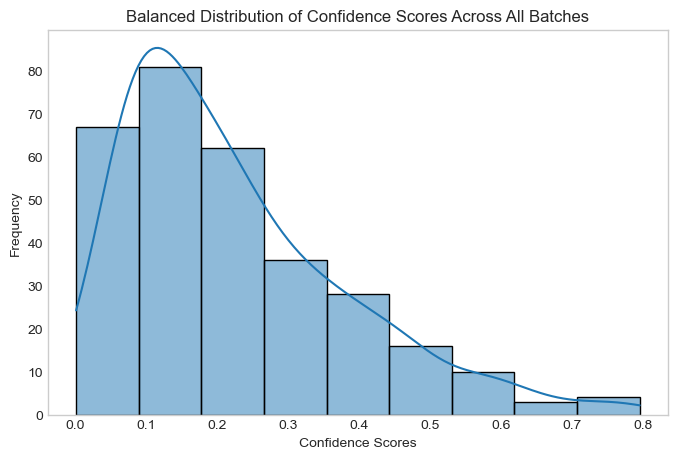

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confidence_distribution(dataloader, N=None, low_conf_fraction=0.5):
    all_confidences = []
    
    for i, batch in enumerate(dataloader):
        if N is not None and i >= N:
            break
        _, _, _, _, confidences = batch
        all_confidences.extend(confidences.cpu().numpy())
    
    all_confidences = np.array(all_confidences)
    
    # Reduce patches with lower confidence scores
    median_conf = np.median(all_confidences)
    low_conf = all_confidences[all_confidences < median_conf]
    high_conf = all_confidences[all_confidences >= median_conf]
    
    # Downsample low-confidence scores
    low_conf = np.random.choice(low_conf, size=int(len(low_conf) * low_conf_fraction), replace=False)
    
    balanced_confidences = np.concatenate([low_conf, high_conf])
    
    # Adjust bins based on new distribution
    min_conf, max_conf = balanced_confidences.min(), balanced_confidences.max()
    bins = np.linspace(min_conf, max_conf, 10)
    
    plt.figure(figsize=(8, 5))
    sns.histplot(balanced_confidences, bins=bins, kde=True)
    plt.xlabel("Confidence Scores")
    plt.ylabel("Frequency")
    plt.title("Balanced Distribution of Confidence Scores Across All Batches")
    plt.grid()
    plt.show()

# Example usage
dl = dm.train_dataloader()
plot_confidence_distribution(dl, low_conf_fraction=0.05)


torch.Size([100])
torch.Size([1])


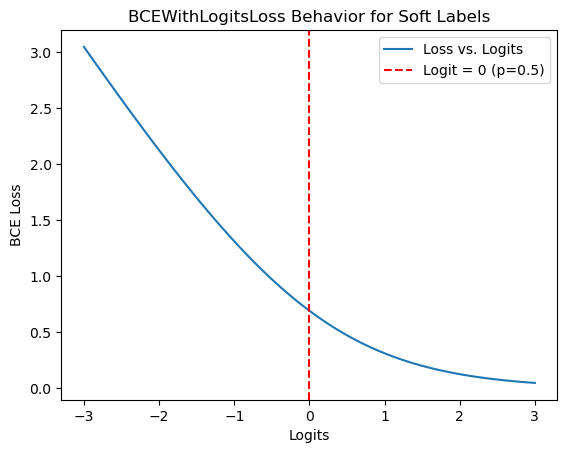

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

logits = torch.linspace(-3, 3, steps=100)  # Logits from -3 to 3
print(logits.shape)
labels = torch.tensor([1.0])  # Example soft label
print(labels.shape)

criterion = nn.BCEWithLogitsLoss()

loss_values = [criterion(l.view(1, 1), labels.view(1, 1)).item() for l in logits]

plt.plot(logits.numpy(), loss_values, label="Loss vs. Logits")
plt.axvline(x=0, color='red', linestyle="--", label="Logit = 0 (p=0.5)")
plt.xlabel("Logits")
plt.ylabel("BCE Loss")
plt.title("BCEWithLogitsLoss Behavior for Soft Labels")
plt.legend()
plt.show()
